Démarrage du script de recherche d'images par texte...
Chargement du modèle d'embedding de texte (par ex. SentenceTransformer)...
Modèle d'embedding de texte chargé.
Chargement des embeddings textuels depuis 'TEXT_EXTRACTED'...
Chargé 2665 caractéristiques textuelles (embeddings) depuis des fichiers .txt.
Dimension d'embedding détectée : 384
Recherche pour la requête prédéfinie : 'a golden color dog'...

Les 10 images les plus proches de votre requête sont :
1. 1_4_chiens_goldenretriever_1570
2. 1_0_chiens_Siberianhusky_928
3. 1_0_chiens_Siberianhusky_900
4. 1_4_chiens_goldenretriever_1434
5. 1_4_chiens_goldenretriever_1479
6. 1_1_chiens_Labradorretriever_1056
7. 1_3_chiens_Chihuahua_1304
8. 1_2_chiens_boxer_1111
9. 1_4_chiens_goldenretriever_1427
10. 1_2_chiens_boxer_1206


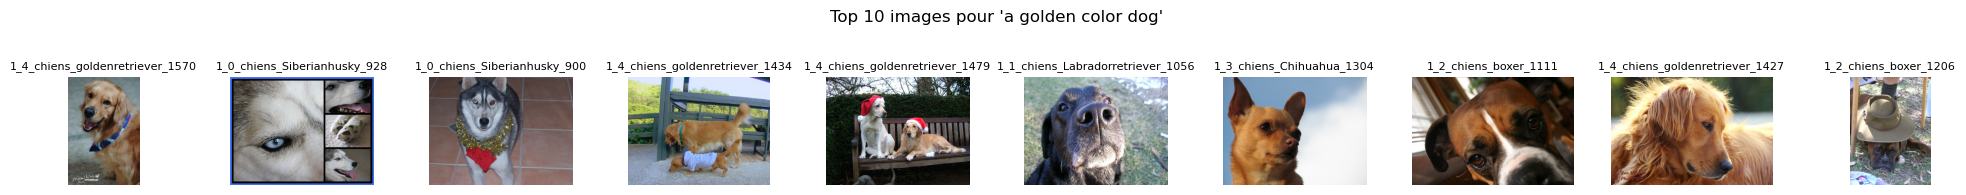

In [ ]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer


In [ ]:

ORIGINAL_IMAGES_DIR = 'MIR_DATASETS_B'
TEXT_EXTRACTED_DIR = 'TEXT_EXTRACTED' # Le répertoire contenant vos fichiers .txt d'embeddings
NUM_NEIGHBORS_TO_DISPLAY = 10
IMAGE_DISPLAY_SIZE = 2

PREDEFINED_QUERY_TEXT = "a golden color dog"


In [ ]:

def load_text_features(directory_path):
    text_features = {}
    if not os.path.isdir(directory_path):
        print(f"Erreur : Le répertoire de caractéristiques textuelles '{directory_path}' n'existe pas.")
        print("Veuillez vous assurer que le dossier 'TEXT_EXTRACTED' existe et contient vos fichiers .txt.")
        return {}

    print(f"Chargement des embeddings textuels depuis '{directory_path}'...")
    for filename in os.listdir(directory_path):
        if filename.endswith(".txt"):
            img_key = os.path.splitext(filename)[0] # Nom du fichier sans extension
            file_path = os.path.join(directory_path, filename)
            try:
                with open(file_path, 'r') as f:
                    embedding_str = f.read().strip()
                    if ',' in embedding_str:
                        embedding = np.array([float(x) for x in embedding_str.split(',')])
                    else:
                        embedding = np.fromstring(embedding_str, sep=' ')

                    text_features[img_key] = embedding
            except Exception as e:
                print(f"Erreur lors du chargement ou de la conversion du fichier '{filename}': {e}")
                continue
    print(f"Chargé {len(text_features)} caractéristiques textuelles (embeddings) depuis des fichiers .txt.")
    return text_features
text_embedding_model = None

def load_text_embedding_model():
    global text_embedding_model
    if text_embedding_model is None:
        print("Chargement du modèle d'embedding de texte (par ex. SentenceTransformer)...")
        try:
            text_embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
            print("Modèle d'embedding de texte chargé.")
        except Exception as e:
            print(f"Erreur lors du chargement du modèle d'embedding de texte : {e}")
            print("Assurez-vous d'avoir 'sentence-transformers' installé et que le modèle est disponible.")
            text_embedding_model = False # Indique une erreur de chargement
    return text_embedding_model


def text_to_vector(query_text, text_features_sample_dim=None):
    model = load_text_embedding_model()
    if model is False: # Model failed to load
        return None
    if model is None: # Model not yet loaded (shouldn't happen if called correctly)
        print("Modèle d'embedding de texte non chargé.")
        return None

    return model.encode(query_text)


def display_images(image_keys, title="Images trouvées"):
    plt.figure(figsize=(IMAGE_DISPLAY_SIZE * len(image_keys), IMAGE_DISPLAY_SIZE))
    plt.suptitle(title)
    for i, img_key in enumerate(image_keys):
        img_path_jpg = os.path.join(ORIGINAL_IMAGES_DIR, f"{img_key}.jpg")
        img_path_png = os.path.join(ORIGINAL_IMAGES_DIR, f"{img_key}.png")

        img_path = None
        if os.path.exists(img_path_jpg):
            img_path = img_path_jpg
        elif os.path.exists(img_path_png):
            img_path = img_path_png

        ax = plt.subplot(1, len(image_keys), i + 1)
        if img_path:
            try:
                img = Image.open(img_path)
                ax.imshow(img)
                ax.set_title(img_key, fontsize=8)
                ax.axis('off')
            except Exception as e:
                print(f"Impossible d'ouvrir l'image {img_path}: {e}")
                ax.text(0.5, 0.5, "Erreur image", ha='center', va='center', fontsize=8)
                ax.set_title(img_key, fontsize=8)
                ax.axis('off')
        else:
            print(f"Image non trouvée pour la clé : {img_key} dans {ORIGINAL_IMAGES_DIR}")
            ax.text(0.5, 0.5, "Image non trouvée", ha='center', va='center', fontsize=8)
            ax.set_title(img_key, fontsize=8)
            ax.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


def search_images_by_text(query_text, text_features_dict, num_neighbors):
    if not text_features_dict:
        print("Aucune caractéristique textuelle chargée. Impossible de procéder à la recherche.")
        return []

    # Déduire la dimension des embeddings à partir des données chargées
    sample_key = next(iter(text_features_dict)) # Prend la première clé
    inferred_embedding_dim = text_features_dict[sample_key].shape[0]

    query_vector = text_to_vector(query_text, inferred_embedding_dim)

    if query_vector is None or query_vector.shape[0] != inferred_embedding_dim:
        print(f"Le vecteur de requête n'a pas la bonne dimension ({query_vector.shape[0] if query_vector is not None else 'None'} au lieu de {inferred_embedding_dim}).")
        print("Vérifiez l'implémentation de 'text_to_vector' et que vos fichiers .txt ont la bonne dimension.")
        return []

    similarities = {}
    for img_key, img_vector in text_features_dict.items():
        try:
            sim = cosine_similarity(query_vector.reshape(1, -1), img_vector.reshape(1, -1))[0][0]
            similarities[img_key] = sim
        except ValueError as e:
            print(f"Erreur de dimension lors de la similarité cosinus pour {img_key}: {e}")
            print(f"Dimension query_vector: {query_vector.shape}, Dimension img_vector: {img_vector.shape}")
            continue

    sorted_images = sorted(similarities.items(), key=lambda item: item[1], reverse=True)

    top_n_images = [img_key for img_key, _ in sorted_images[:num_neighbors]]
    return top_n_images

In [ ]:

if __name__ == "__main__":
    print("Démarrage du script de recherche d'images par texte...")

    # Vérifier l'existence du répertoire des images originales
    if not os.path.isdir(ORIGINAL_IMAGES_DIR):
        print(f"Erreur : Le répertoire des images originales '{ORIGINAL_IMAGES_DIR}' n'existe pas.")
        print("Veuillez vérifier le chemin ou créer ce dossier et y placer vos images.")
        exit()

    # Charger le modèle d'embedding de texte une fois au démarrage
    if load_text_embedding_model() is False:
        print("Impossible de charger le modèle d'embedding de texte. Arrêt du script.")
        exit()

    # 1. Charger les caractéristiques textuelles depuis le répertoire
    extracted_text_data = load_text_features(TEXT_EXTRACTED_DIR)

    if not extracted_text_data:
        print("Le script ne peut pas continuer sans données textuelles chargées.")
        exit()

    # Déduire la dimension des embeddings une fois que les données sont chargées
    sample_key = next(iter(extracted_text_data))
    inferred_embedding_dim = extracted_text_data[sample_key].shape[0]
    print(f"Dimension d'embedding détectée : {inferred_embedding_dim}")

    # Utilisation de la requête prédéfinie
    user_query = PREDEFINED_QUERY_TEXT

    if user_query is None or not user_query.strip():
        print("Aucune requête textuelle prédéfinie ou elle est vide. Veuillez définir 'PREDEFINED_QUERY_TEXT'.")
        exit() # Arrête le script si la requête prédéfinie est vide

    print(f"Recherche pour la requête prédéfinie : '{user_query}'...")
    # 2. Rechercher les images les plus proches
    closest_images = search_images_by_text(user_query, extracted_text_data, NUM_NEIGHBORS_TO_DISPLAY)

    if closest_images:
        print(f"\nLes {NUM_NEIGHBORS_TO_DISPLAY} images les plus proches de votre requête sont :")
        for i, img_key in enumerate(closest_images):
            print(f"{i+1}. {img_key}")
        # 3. Afficher les images
        display_images(closest_images, title=f"Top {NUM_NEIGHBORS_TO_DISPLAY} images pour '{user_query}'")
    else:
        print("Aucune image trouvée pour cette requête. Vérifiez vos données et la fonction 'text_to_vector'.")